In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv("housing.csv")

df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [3]:
print("Shape:", df.shape)

df.info()


Shape: (20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB


In [4]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [7]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


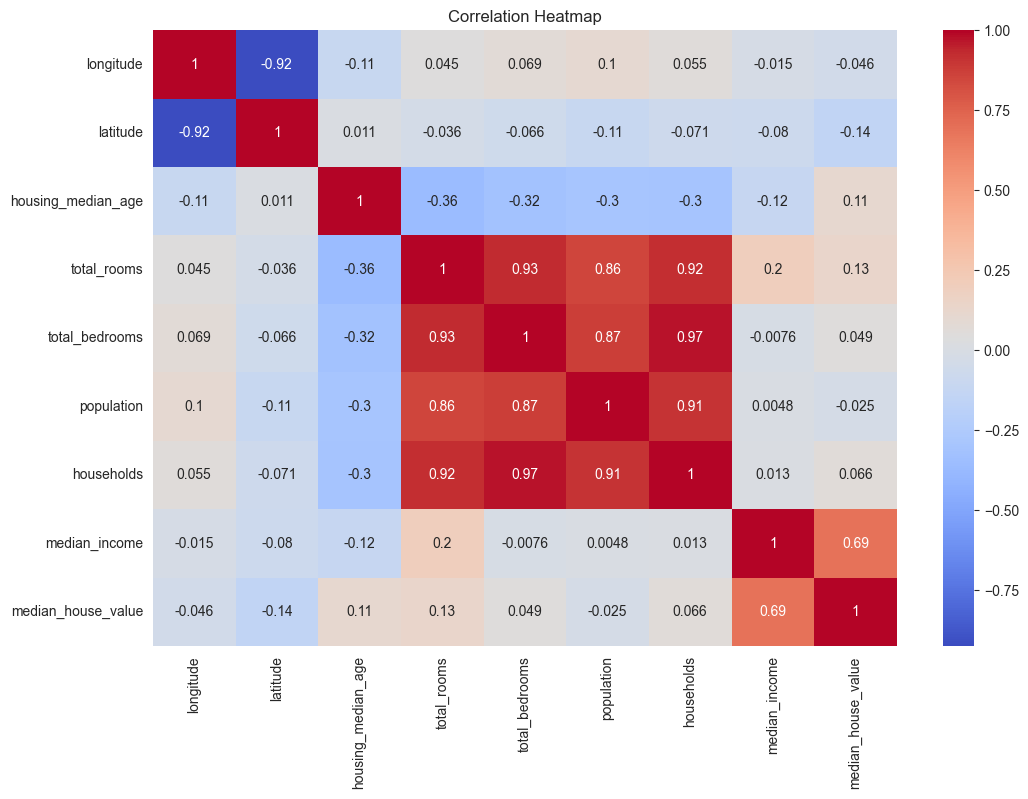

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

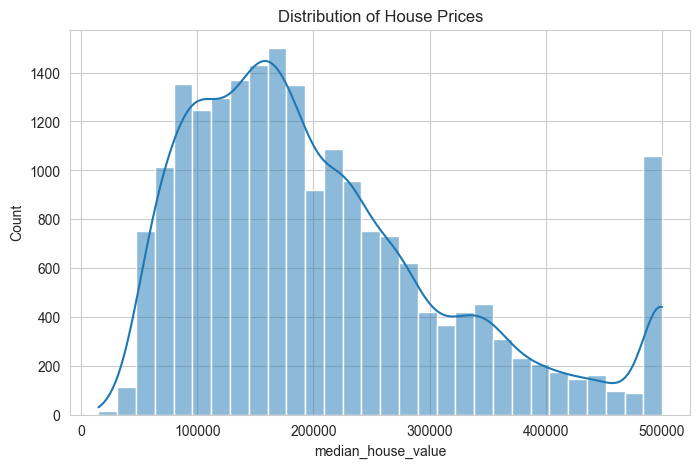

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["median_house_value"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.show()

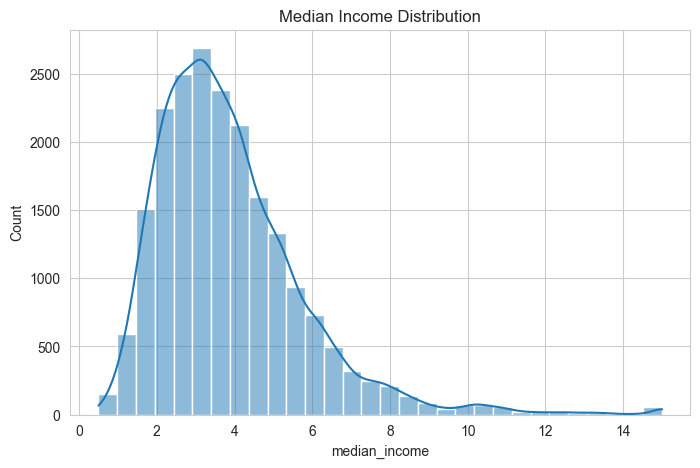

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["median_income"],
    bins=30,
    kde=True
)

plt.title("Median Income Distribution")
plt.show()

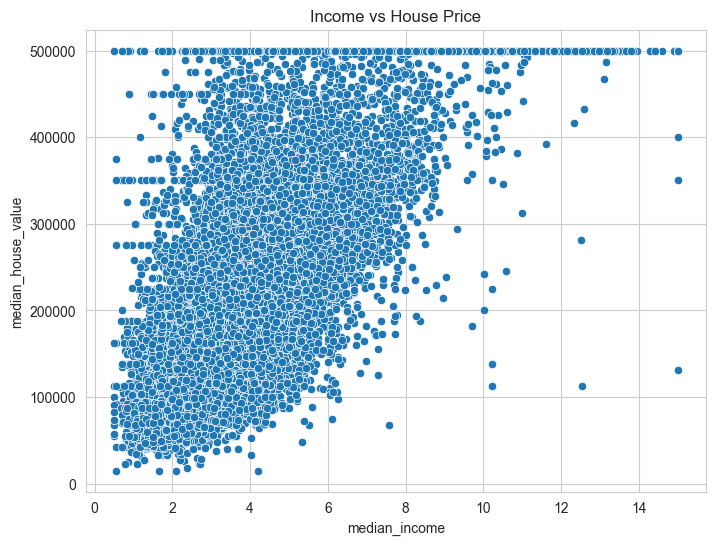

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="median_income",
    y="median_house_value",
    data=df
)

plt.title("Income vs House Price")
plt.show()


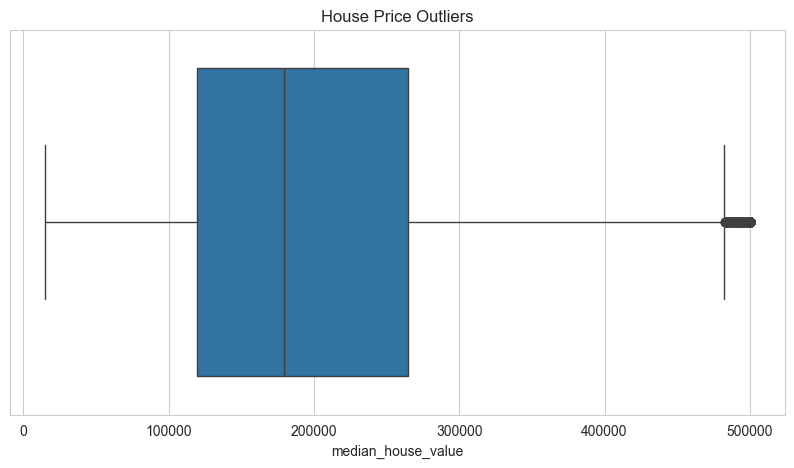

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["median_house_value"])

plt.title("House Price Outliers")
plt.show()

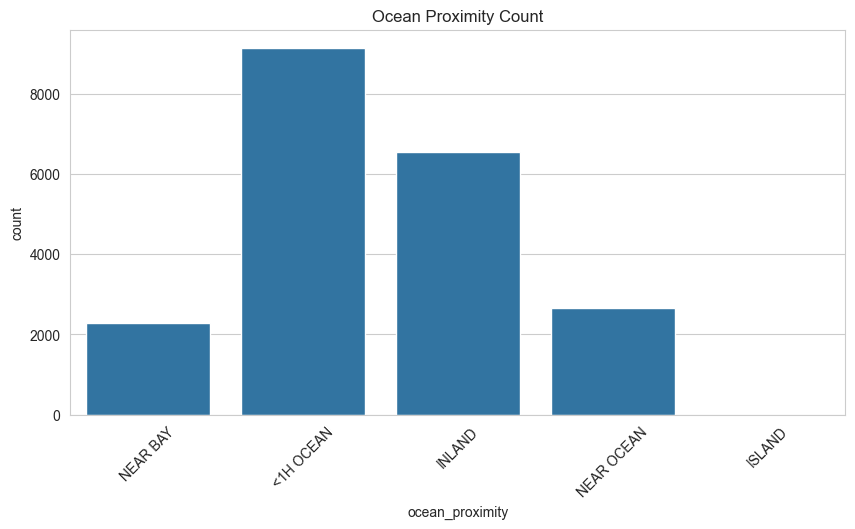

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="ocean_proximity",
    data=df
)

plt.xticks(rotation=45)
plt.title("Ocean Proximity Count")
plt.show()

In [14]:
avg_price = df.groupby(
    "ocean_proximity"
)["median_house_value"].mean()

print(avg_price)

ocean_proximity
<1H OCEAN     240084.285464
INLAND        124805.392001
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
Name: median_house_value, dtype: float64


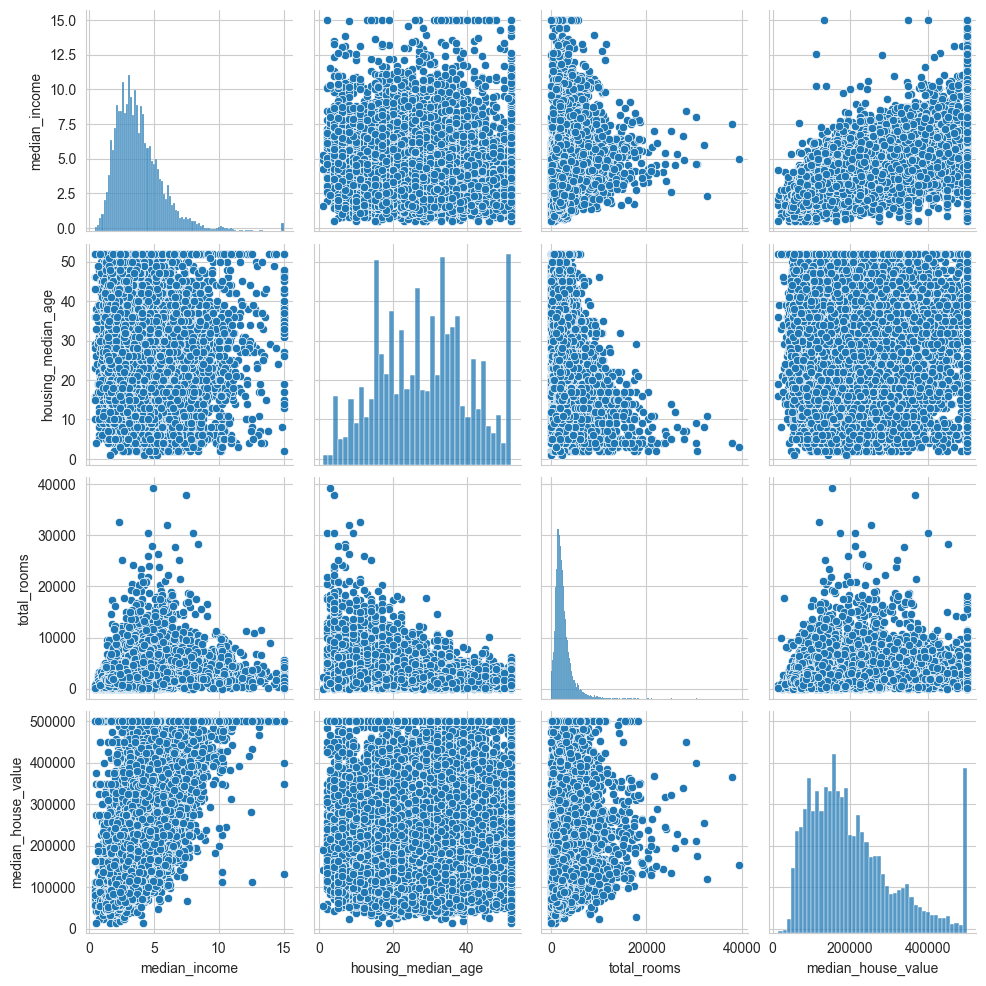

In [15]:
sns.pairplot(
    df[
        [
            "median_income",
            "housing_median_age",
            "total_rooms",
            "median_house_value"
        ]
    ]
)

plt.show()



In [16]:
df["rooms_per_household"] = (
    df["total_rooms"] /
    df["households"]
)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,6.984127
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,6.238137
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,8.288136
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,5.817352
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,6.281853


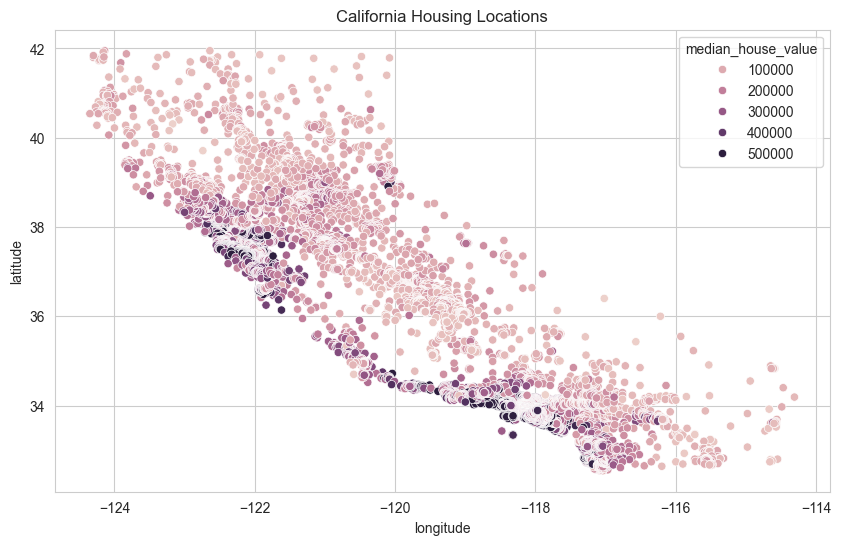

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="longitude",
    y="latitude",
    hue="median_house_value",
    data=df
)

plt.title("California Housing Locations")
plt.show()

# Business Insights

1. Median income has strong positive correlation with house prices.

2. Houses near the ocean are generally more expensive.

3. Median house value contains several outliers.

4. Geographic location strongly influences prices.

5. Most houses belong to moderate income regions.

6. Rooms per household may help improve predictive models.